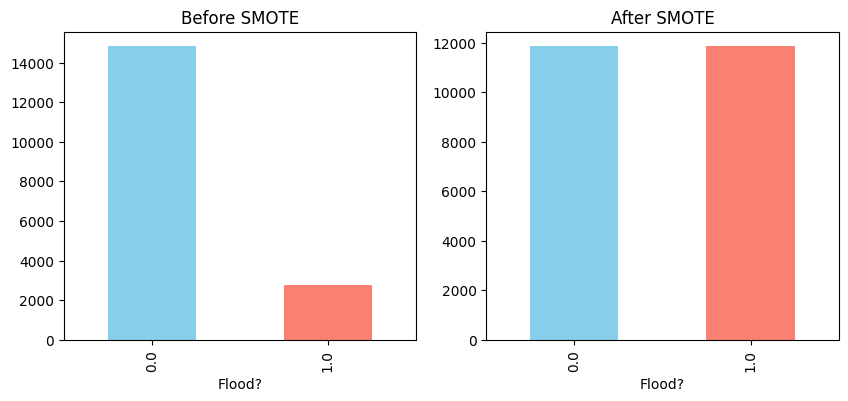

✅ Classification Report (Threshold 0.5):
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97      2963
         1.0       0.78      0.98      0.87       549

    accuracy                           0.95      3512
   macro avg       0.89      0.96      0.92      3512
weighted avg       0.96      0.95      0.96      3512



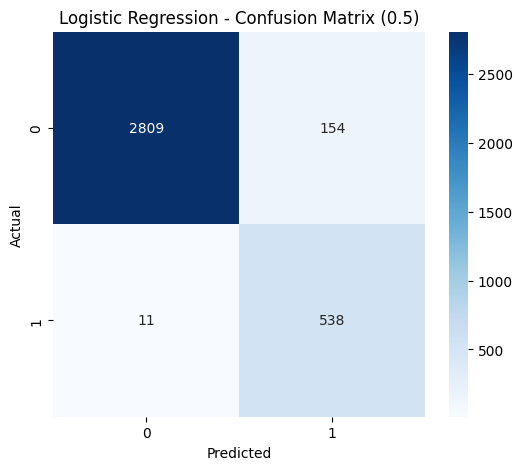

ROC-AUC Score: 0.9930933240383676
Threshold Tuning Results:
     Threshold  Precision    Recall  F1-score
0        0.10   0.559671  0.990893  0.715319
1        0.15   0.591948  0.990893  0.741144
2        0.20   0.621714  0.990893  0.764045
3        0.25   0.647619  0.990893  0.783297
4        0.30   0.676214  0.989071  0.803254
5        0.35   0.704427  0.985428  0.821564
6        0.40   0.725437  0.981785  0.834365
7        0.45   0.751397  0.979964  0.850593
8        0.50   0.777457  0.979964  0.867043
9        0.55   0.799701  0.974499  0.878489
10       0.60   0.823802  0.970856  0.891304
11       0.65   0.839937  0.965392  0.898305
12       0.70   0.867330  0.952641  0.907986
13       0.75   0.904594  0.932605  0.918386
14       0.80   0.920074  0.901639  0.910764
15       0.85   0.938900  0.839709  0.886538

✅ Classification Report at Threshold 0.35:
              precision    recall  f1-score   support

         0.0       1.00      0.92      0.96      2963
         1.0       0.

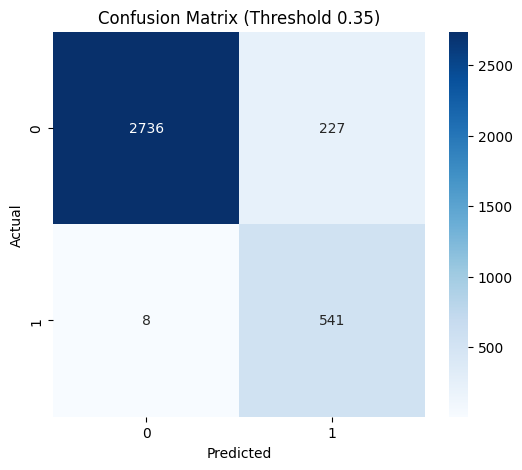

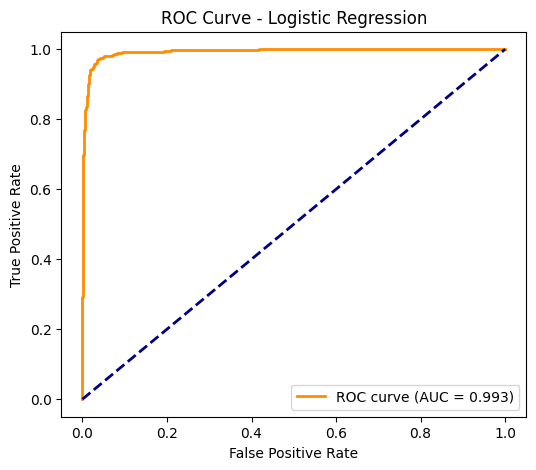

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('flood_data_preprocessed.csv')

numeric_features = ['Max_Temp','Min_Temp','Rainfall log','Relative_Humidity','Wind_Speed log',
                    'Cloud_Coverage','Bright_Sunshine','X_COR','Y_COR','LATITUDE','LONGITUDE','ALT log','Period']

# One-hot encode categorical column
df_dummies = pd.get_dummies(df[['Station_Names']], drop_first=True)

# Combine numeric and categorical features
X = pd.concat([df[numeric_features], df_dummies], axis=1)
y = df['Flood?']

# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale Numeric Features

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])


# Handle Imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Visualize class distribution
fig, ax = plt.subplots(1, 2, figsize=(10,4))
y.value_counts().plot(kind='bar', ax=ax[0], title='Before SMOTE', color=['skyblue','salmon'])
y_train_res.value_counts().plot(kind='bar', ax=ax[1], title='After SMOTE', color=['skyblue','salmon'])
plt.show()


# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_res, y_train_res)

# Predictions and Probabilities
y_pred = lr_model.predict(X_test)
y_proba = lr_model.predict_proba(X_test)[:,1]

# Evaluate Default Threshold (0.5)
print("✅ Classification Report (Threshold 0.5):")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix (0.5)')
plt.show()

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)


# Threshold Tuning
thresholds = np.arange(0.1, 0.9, 0.05)
results_thresh = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_thresh, average='binary')
    results_thresh.append([t, precision, recall, f1])

results_df = pd.DataFrame(results_thresh, columns=['Threshold','Precision','Recall','F1-score'])
print("Threshold Tuning Results:\n", results_df)

# Choose best threshold (high recall for flood detection)
best_threshold = 0.35
y_pred_best = (y_proba >= best_threshold).astype(int)
print(f"\n✅ Classification Report at Threshold {best_threshold}:")
print(classification_report(y_test, y_pred_best))

# Confusion matrix for best threshold
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Threshold {best_threshold})')
plt.show()

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.show()
